In [10]:
# all imports 
import pandas as pd
import re
from collections import Counter
import matplotlib.pyplot as plt
import nltk
from wordcloud import WordCloud

### looking at data

In [11]:
df = pd.read_csv('/Users/Diane/Desktop/PSYCH 186B/project/reviews_Parasite_RT.csv')
df

,movie_title,tomatometer,popcornmeter,review_type,reviewer,publication,score,date,review_text
0,Parasite,99%,NaN,critic,Julian Singleton,Cinapse,NaN,Jul 12,A raucous rollercoaster of genre from sleek cr...
1,Parasite,99%,NaN,critic,Sharai Bohannon,A Nightmare On Fierce Street Podcast,5/5,Jun 23,Korean cinema is always that girl. Part of the...
2,Parasite,99%,NaN,critic,Emma Simmonds,Radio Times,5/5,08/30/2024,"It's a wonderfully sneaky film that, before yo..."
3,Parasite,99%,NaN,critic,Denise Pieniazek,Puesta en Escena (AR),9.5,08/15/2024,"Fundamentally, Parasite aims to make us reflec..."
4,Parasite,99%,NaN,critic,Diana Tuova,Spotlight on Film,5/5,07/30/2024,Parasite is both darkly hilarious and delightf...
...,...,...,...,...,...,...,...,...,...
95,Parasite,99%,NaN,audience,Joni,NaN,NaN,03/08/2020,Full of plottwists backed-up with a good story...
96,Parasite,99%,NaN,audience,andi p,NaN,NaN,03/08/2020,"Incredible film. Haunting, beautiful. Absolute..."
97,Parasite,99%,NaN,audience,Ellen K,NaN,NaN,03/07/2020,It was okay once I got used to reading the wor...
98,Parasite,99%,NaN,audience,Andrew L,NaN,NaN,03/07/2020,Amazing story. One of a kind.See MoreSee Less


need to think about how to turn this into a function!!

In [ ]:
# do i need this code every time 
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

# preprocessing the data 
lex = pd.read_csv("/Users/Diane/Desktop/PSYCH 186B/project/NRC-Emotion-Lexicon-Wordlevel-v0.92.txt", sep='\t', names=['word', 'emotion', 'assoc'])
lex = lex[lex['assoc'] == 1]

emotion_map = lex.groupby('word')['emotion'].apply(list).to_dict()
print("Review dataset columns:", df.columns)

Review dataset columns: Index(['movie_title', 'tomatometer', 'popcornmeter', 'review_type', 'reviewer',
       'publication', 'score', 'date', 'review_text'],
      dtype='object')


[nltk_data] Downloading package stopwords to /Users/Diane/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [7]:
df.columns

Index(['movie_title', 'tomatometer', 'popcornmeter', 'review_type', 'reviewer',
       'publication', 'score', 'date', 'review_text', 'emotion_counts',
       'emotion_normalized', 'negative', 'positive', 'anger', 'disgust',
       'fear', 'sadness', 'surprise', 'anticipation', 'joy', 'trust'],
      dtype='object')

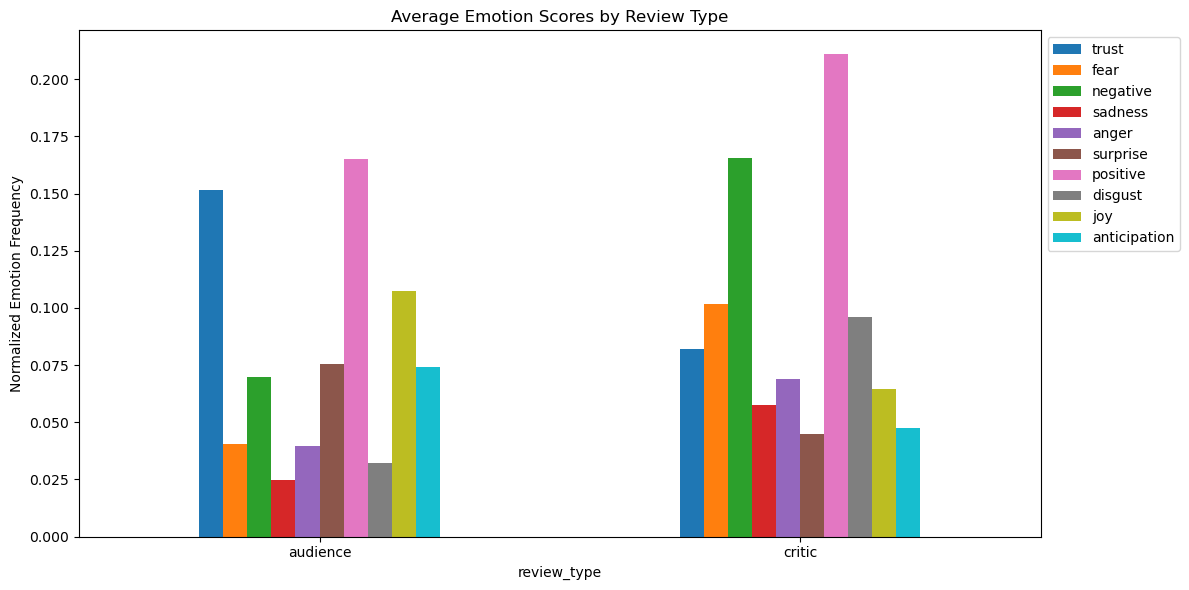

In [ ]:
# define necessary functions 

def simple_tokenizer(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|[^a-z\s]", "", text)
    return [word for word in text.split() if word not in stop_words]

def get_emotions(text):
    words = simple_tokenizer(text)
    emotions = [emo for word in words for emo in emotion_map.get(word, [])]
    return Counter(emotions)

def normalize(counter):
    total = sum(counter.values())
    return {emotion: count / total for emotion, count in counter.items()} if total > 0 else {}

# apply functions 
df['emotion_counts'] = df['review_text'].apply(get_emotions)
df['emotion_normalized'] = df['emotion_counts'].apply(normalize)

# split into columns 
emotion_df = df['emotion_normalized'].apply(pd.Series).fillna(0)
df = pd.concat([df, emotion_df], axis=1)

# average by group 
type_col = 'review_type'
emotion_cols = lex['emotion'].unique().tolist()
grouped = df.groupby(type_col)[emotion_cols].mean()

# average counts plot
grouped.plot(kind='bar', figsize=(12, 6))
plt.title("Average Emotion Scores by Review Type")
plt.ylabel("Normalized Emotion Frequency")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


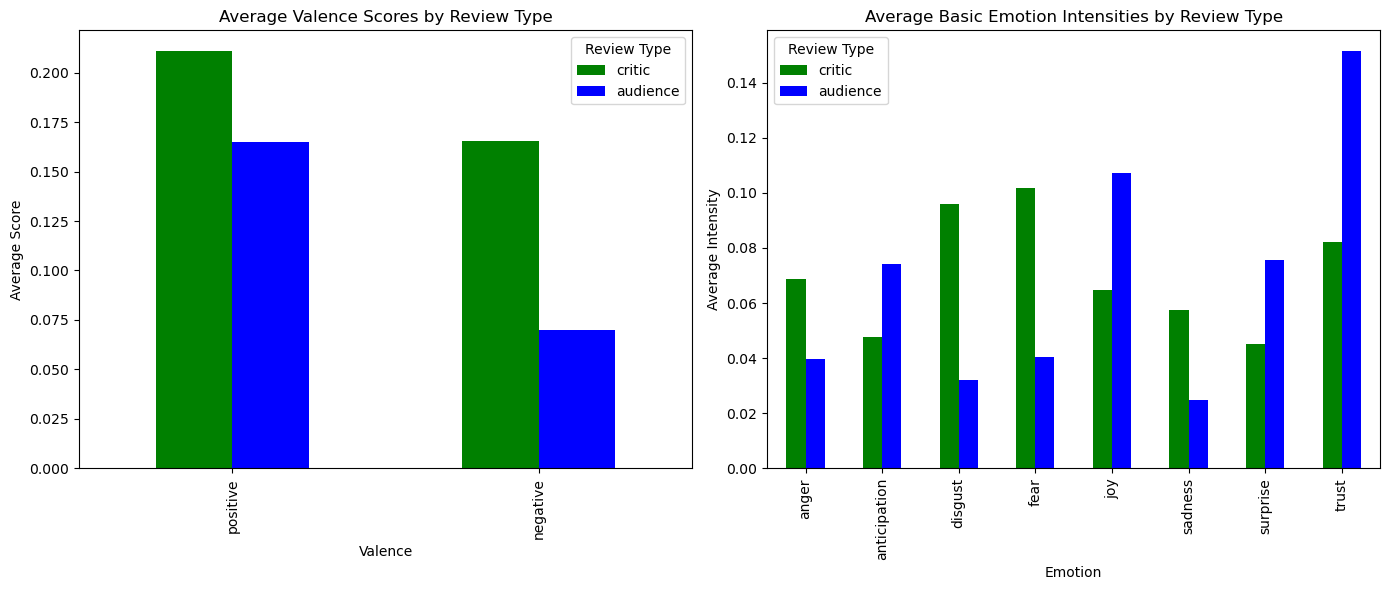

In [6]:
valence_emotions = ['positive', 'negative']
basic_emotions = ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'sadness', 'surprise', 'trust']

for emotion in valence_emotions + basic_emotions:
    if emotion not in df.columns:
        df[emotion] = 0.0

types = ['critic', 'audience'] 

# mean calculations 
valence_means = df.groupby('review_type')[valence_emotions].mean().loc[types]
emotion_means = df.groupby('review_type')[basic_emotions].mean().loc[types]

# valence bar graph 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

valence_means.T.plot(kind='bar', ax=axes[0], color=['green', 'blue'])
axes[0].set_title('Average Valence Scores by Review Type')
axes[0].set_ylabel('Average Score')
axes[0].set_xlabel('Valence')
axes[0].legend(title='Review Type')

# emotions bar graph 
emotion_means.T.plot(kind='bar', ax=axes[1], color=['green', 'blue'])
axes[1].set_title('Average Basic Emotion Intensities by Review Type')
axes[1].set_ylabel('Average Intensity')
axes[1].set_xlabel('Emotion')
axes[1].legend(title='Review Type')

plt.tight_layout()
plt.show()

### word cloud 

In [ ]:
# need to fix 

all_tokens = []
for t in df[tweet_col].dropna().astype(str):
    all_tokens.extend(simple_tokenizer(t))

freq_counter = Counter(all_tokens)

top_n = 20 
most_common_words = set([w for w, count in freq_counter.most_common(top_n)])
print(f"Top {top_n} most common words being excluded:", most_common_words)

for party in df[party_col].unique():
    party_texts = df[df[party_col] == party][tweet_col].dropna().astype(str)
    tokens = []
    for t in party_texts:
        tokens.extend(simple_tokenizer(t))
    
    filtered_tokens = [w for w in tokens if w not in most_common_words]
    filtered_text = ' '.join(filtered_tokens)
    
    if filtered_text.strip():
        wordcloud = WordCloud(width=800, height=400, background_color='white').generate(filtered_text)
        
        plt.figure(figsize=(15, 7))
        plt.imshow(wordcloud, interpolation='bilinear')
        plt.axis('off')
        plt.title(f"Most Frequent Words (Topics) for {party} (excluding top {top_n} global words)")
        plt.show()
    else:
        print(f"No text data for party: {party}")

notes: 
* labeling criteria: profitable (1): gross / budget >= 3.0, not profitable (0): gross / budget <  3.0

In [12]:
df.columns

Index(['movie_title', 'tomatometer', 'popcornmeter', 'review_type', 'reviewer',
       'publication', 'score', 'date', 'review_text'],
      dtype='object')

In [ ]:
import re
import numpy as np
import pandas as pd
from typing import Optional

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# functions

def assign_label(row: pd.Series):
    budget = row.get("budget", np.nan) # need to somehow pass in budget and gross 
    gross  = row.get("gross",  np.nan)

    if pd.notna(budget) and budget > 0 and pd.notna(gross):
        return 1 if (gross / budget) >= 3.0 else 0
    
    return np.nan   # will be dropped

def label_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # keep the rows w/ no valid target here bc keeping them would cause a crash when pytorch tries to load NaN into a tensor
    df["label"] = df.apply(assign_label, axis=1)
    df = df.dropna(subset=["label"])
    # int is needed so stratified split and value_counts rename works 
    df["label"] = df["label"].astype(int)
    return df


# 2. datapreprocessing 

# reminder to figure out if we're gonna get the separate scores 
NUMERIC_FEATURES = [
    "avg_critic_score",
    "avg_audience_score",
    "combined_score",
    "budget",
    "gross",
    "roi",
]

def preprocess(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    # normalize score columns to 0-10, coerce turns non numeric strings into NaN 
    for col in ("avg_critic_score", "avg_audience_score", "combined_score", "score"):
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    # Aggregate reviews per movie 
    # collapse mrows so model sees 1 row / movie, reviews joined w/ SEP so BERT can distinguish 
    # do we need this tho
    agg: dict = {"review_text": lambda x: " [SEP] ".join(x.dropna().astype(str))}

    # for numeric site-level columns, average across all rows for that movie
    for col in ("avg_critic_score", "avg_audience_score", "combined_score",
                "budget", "gross"):
        if col in df.columns:
            agg[col] = "mean"

    # If only a flat 'score' column exists (no pre-split critic/audience columns),
    # derive avg_critic_score and avg_audience_score ourselves using review_type.
    if "score" in df.columns and "review_type" in df.columns:
        def split_scores(g):
            # Filter rows by review_type to compute separate averages.
            # .mean() on an empty slice returns NaN, which is handled downstream.
            critics  = g.loc[g["review_type"].str.lower() == "critic",  "score"].mean()
            audience = g.loc[g["review_type"].str.lower() == "audience", "score"].mean()
            combined = g["score"].mean()   # overall average regardless of type
            return pd.Series({
                "avg_critic_score":   critics,
                "avg_audience_score": audience,
                "combined_score":     combined,
            })
        score_agg = df.groupby("movie_title").apply(split_scores).reset_index()
        agg.pop("score", None)   # remove raw 'score' so it isn't double-counted
        movie_df = df.groupby("movie_title").agg(agg).reset_index()
        movie_df = movie_df.merge(score_agg, on="movie_title", how="left")
    else:
        movie_df = df.groupby("movie_title").agg(agg).reset_index()

    # ── ROI feature ───────────────────────────────────────────────────
    # Compute gross/budget as an explicit feature so the model doesn't have
    # to learn the division relationship itself from raw budget and gross.
    # np.where is used instead of a lambda so NaN propagates cleanly when
    # either value is missing or budget is zero (avoid division by zero).
    movie_df["roi"] = np.where(
        (movie_df["budget"] > 0) & movie_df["budget"].notna() & movie_df["gross"].notna(),
        movie_df["gross"] / movie_df["budget"],
        np.nan,
    )

    # ── Labels ────────────────────────────────────────────────────────
    movie_df = label_dataset(movie_df)

    return movie_df


def build_numeric_matrix(movie_df: pd.DataFrame, scaler: Optional[StandardScaler] = None):
    """Return scaled numeric array + fitted scaler."""
    # Only keep columns that actually exist in this dataset —
    # not all scrapes will have every feature (e.g. some may lack critic scores).
    cols = [c for c in NUMERIC_FEATURES if c in movie_df.columns]
    # Fill remaining NaNs with 0 before scaling. The scaler will then centre
    # and normalise each column so no single feature dominates by magnitude.
    X_num = movie_df[cols].fillna(0).values.astype(np.float32)
    if scaler is None:
        # Training time: fit the scaler on training data only, then transform.
        # Fitting on val/test would leak distribution info into the scaler.
        scaler = StandardScaler()
        X_num = scaler.fit_transform(X_num)
    else:
        # Val/test time: reuse the scaler fitted on training data.
        X_num = scaler.transform(X_num)
    return X_num, scaler, cols


# ─────────────────────────────────────────────
#  3. DATASET
# ─────────────────────────────────────────────

class MovieDataset(Dataset):
    def __init__(self, texts, numeric_features, labels, tokenizer, max_len=256):
        self.texts    = texts
        self.numeric  = torch.tensor(numeric_features, dtype=torch.float32)
        # Labels must be float32 (not long) because BCEWithLogitsLoss computes
        # a continuous sigmoid probability and compares it against a float target.
        # CrossEntropyLoss used integer class indices; BCE does not.
        self.labels   = torch.tensor(labels, dtype=torch.float32)
        self.tok      = tokenizer
        self.max_len  = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Tokenise on-the-fly per sample. max_length caps the token count;
        # truncation drops excess tokens; padding pads shorter sequences to
        # max_length so all samples in a batch have the same shape.
        enc = self.tok(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors="pt",
        )
        return {
            # squeeze(0) removes the batch dimension the tokeniser adds,
            # since DataLoader will re-add it when stacking samples into a batch.
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "numeric":        self.numeric[idx],
            "label":          self.labels[idx],
        }


# ─────────────────────────────────────────────
#  4. MODEL — Nonlinear Associator Classifier
# ─────────────────────────────────────────────

class MovieClassifier(nn.Module):
    """
    Text branch   : BERT [CLS] embedding  (768-d)
    Numeric branch: MLP over scaled numeric features
    Fusion        : concatenation → deep MLP → binary output (sigmoid)

    Output is a single logit; apply sigmoid to get P(profitable).
    """
    def __init__(self, numeric_dim: int, hidden_dim: int = 256, dropout: float = 0.3):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")

        # Freeze all BERT parameters first, then selectively unfreeze the top
        # two transformer encoder blocks (layers 10 and 11). Lower layers capture
        # general language features that transfer well and don't need retraining;
        # upper layers are more task-specific and benefit from fine-tuning on our data.
        # Freezing most of BERT also significantly reduces GPU memory and training time.
        for name, param in self.bert.named_parameters():
            if not any(f"encoder.layer.{i}" in name for i in [10, 11]):
                param.requires_grad = False

        bert_dim = self.bert.config.hidden_size  # 768 for bert-base

        # ── Numeric MLP branch ────────────────────────────────────────
        # A small two-layer MLP compresses the numeric features into a
        # 64-dimensional embedding before fusion. ReLU introduces nonlinearity
        # so the branch can learn interactions between features (e.g. how
        # budget interacts with critic score) rather than just linear combinations.
        # Dropout regularises by randomly zeroing activations during training,
        # reducing overfitting on the numeric side.
        self.numeric_branch = nn.Sequential(
            nn.Linear(numeric_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

        # ── Fusion MLP ────────────────────────────────────────────────
        # Concatenate the 768-d BERT [CLS] embedding and the 64-d numeric
        # embedding into a single 832-d vector, then pass through a deep MLP.
        # The fusion layers learn how text sentiment and numeric signals
        # jointly predict profitability — neither branch alone is sufficient.
        fusion_in = bert_dim + 64   # 768 + 64 = 832
        self.fusion = nn.Sequential(
            nn.Linear(fusion_in, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            # Single output neuron: produces one raw logit (no activation here).
            # BCEWithLogitsLoss applies sigmoid internally, which is more
            # numerically stable than applying sigmoid here and then using BCELoss.
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, input_ids, attention_mask, numeric):
        bert_out  = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # The [CLS] token (index 0) is BERT's aggregate sentence representation —
        # it's trained to summarise the entire input, making it ideal for classification.
        cls_embed = bert_out.last_hidden_state[:, 0, :]   # [B, 768]
        num_embed = self.numeric_branch(numeric)           # [B, 64]
        # Concatenate along the feature dimension to combine both modalities.
        fused     = torch.cat([cls_embed, num_embed], dim=1)   # [B, 832]
        # squeeze(1) collapses [B, 1] → [B] to match the label tensor shape
        # expected by BCEWithLogitsLoss.
        logits    = self.fusion(fused).squeeze(1)          # [B]
        return logits


# ─────────────────────────────────────────────
#  5. TRAINING LOOP
# ─────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, device):
    model.train()   # activates dropout and batch norm (if any) during training
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        numeric   = batch["numeric"].to(device)
        labels    = batch["label"].to(device)   # float32 for BCEWithLogitsLoss

        # Zero gradients before each backward pass — PyTorch accumulates
        # gradients by default, so we must clear them each step.
        optimizer.zero_grad()
        logits = model(input_ids, attn_mask, numeric)   # raw logits, shape [B]
        loss   = criterion(logits, labels)              # BCE loss (sigmoid applied internally)
        loss.backward()                                 # compute gradients
        # Clip gradients to max norm of 1.0 to prevent exploding gradients,
        # which are common when fine-tuning large pretrained models like BERT.
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()   # update weights

        # Apply sigmoid to convert logits to probabilities, then threshold at 0.5
        # to get binary predictions. This is separate from the loss (which handles
        # sigmoid internally) and is only used for tracking accuracy.
        preds = (torch.sigmoid(logits) >= 0.5).float()
        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()   # disables gradient tracking to save memory and speed up inference
def evaluate(model, loader, criterion, device):
    model.eval()   # disables dropout so predictions are deterministic
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attn_mask = batch["attention_mask"].to(device)
        numeric   = batch["numeric"].to(device)
        labels    = batch["label"].to(device)   # float32

        logits = model(input_ids, attn_mask, numeric)
        loss   = criterion(logits, labels)

        # Same sigmoid + threshold logic as train_epoch, but here we also
        # collect all predictions and labels to compute the full classification
        # report and confusion matrix after the loop.
        preds = (torch.sigmoid(logits) >= 0.5).float()
        total_loss += loss.item() * labels.size(0)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)
        # Cast to int before collecting so sklearn's classification_report
        # receives integer 0/1 values rather than floats.
        all_preds.extend(preds.cpu().int().tolist())
        all_labels.extend(labels.cpu().int().tolist())

    return total_loss / total, correct / total, all_preds, all_labels


# ─────────────────────────────────────────────
#  6. MAIN — put it all together
# ─────────────────────────────────────────────

def main(
    csv_path: str,
    epochs: int = 5,
    batch_size: int = 16,
    lr: float = 2e-5,
    max_len: int = 256,
    dropout: float = 0.3,
    seed: int = 42,
):
    torch.manual_seed(seed)   # makes weight init and data shuffling reproducible
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # ── Load & preprocess ─────────────────────────────────────────────
    raw_df   = pd.read_csv(csv_path)
    movie_df = preprocess(raw_df)   # aggregate reviews, engineer ROI, assign labels

    print("\nLabel distribution:")
    # Check for class imbalance here — if one class dominates heavily you may
    # want to pass pos_weight to BCEWithLogitsLoss or oversample the minority class.
    print(movie_df["label"].value_counts().rename({0: "Not Profitable", 1: "Profitable"}))

    # ── Train/val/test split ──────────────────────────────────────────
    # stratify= ensures each split has the same class ratio as the full dataset,
    # which is important if classes are imbalanced.
    train_df, test_df = train_test_split(movie_df, test_size=0.15, random_state=seed,
                                         stratify=movie_df["label"])
    train_df, val_df  = train_test_split(train_df,  test_size=0.15, random_state=seed,
                                         stratify=train_df["label"])

    # Fit scaler on training data only, then apply to val and test.
    # Passing the fitted scaler to subsequent calls prevents data leakage.
    X_train, scaler, num_cols = build_numeric_matrix(train_df)
    X_val,  _,  _             = build_numeric_matrix(val_df,  scaler)
    X_test, _,  _             = build_numeric_matrix(test_df, scaler)
    print(f"\nNumeric features used: {num_cols}")

    # ── Tokenizer & Datasets ──────────────────────────────────────────
    tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

    train_ds = MovieDataset(train_df["review_text"].tolist(), X_train,
                            train_df["label"].tolist(), tokenizer, max_len)
    val_ds   = MovieDataset(val_df["review_text"].tolist(),   X_val,
                            val_df["label"].tolist(),   tokenizer, max_len)
    test_ds  = MovieDataset(test_df["review_text"].tolist(),  X_test,
                            test_df["label"].tolist(),  tokenizer, max_len)

    # shuffle=True on train loader randomises batch order each epoch, which
    # helps the model generalise. Val and test loaders don't need shuffling.
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size)

    # ── Model, loss, optimiser ────────────────────────────────────────
    model     = MovieClassifier(numeric_dim=X_train.shape[1], dropout=dropout).to(device)
    # BCEWithLogitsLoss combines sigmoid + binary cross-entropy in one numerically
    # stable operation. It expects raw logits (not sigmoid-activated outputs).
    criterion = nn.BCEWithLogitsLoss()
    # AdamW is Adam with decoupled weight decay — preferred over plain Adam for
    # transformer fine-tuning as it regularises weights without affecting gradients.
    # filter(...) ensures we only pass parameters that require gradients (unfrozen ones).
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()), lr=lr
    )
    # Cosine annealing smoothly decays the learning rate from lr down to ~0 over
    # T_max epochs, helping the model converge without oscillating near the minimum.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # ── Training ──────────────────────────────────────────────────────
    # Track the best validation accuracy and save that model state —
    # the final epoch is not necessarily the best due to overfitting.
    best_val_acc, best_state = 0.0, None
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, device)
        vl_loss, vl_acc, _, _ = evaluate(model, val_loader, criterion, device)
        scheduler.step()

        print(f"Epoch {epoch}/{epochs}  "
              f"train_loss={tr_loss:.4f} train_acc={tr_acc:.3f}  "
              f"val_loss={vl_loss:.4f} val_acc={vl_acc:.3f}")

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            # Clone weights to CPU so they're preserved even if training continues
            # and modifies the model in-place on GPU.
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ── Test evaluation ───────────────────────────────────────────────
    # Restore best checkpoint before final evaluation on held-out test set.
    model.load_state_dict(best_state)
    model.to(device)
    _, test_acc, preds, labels = evaluate(model, test_loader, criterion, device)

    label_names = ["Not Profitable", "Profitable"]
    print(f"\nTest Accuracy: {test_acc:.3f}")
    print("\nClassification Report:")
    print(classification_report(labels, preds, target_names=label_names))
    print("Confusion Matrix:")
    print(confusion_matrix(labels, preds))

    # Save
    torch.save({"model_state": best_state, "scaler": scaler, "num_cols": num_cols},
               "movie_classifier.pt")
    print("\nModel saved to movie_classifier.pt")
    return model, scaler


# ─────────────────────────────────────────────
#  7. INFERENCE — classify a new movie
# ─────────────────────────────────────────────

def predict_movie(
    model: MovieClassifier,
    scaler: StandardScaler,
    num_cols: list,
    review_texts: list[str],
    numeric_data: dict,
    tokenizer=None,
    device=None,
    max_len: int = 256,
) -> dict:
    """
    Predict a single movie at inference time.

    Parameters
    ----------
    review_texts : list of review strings for this movie
    numeric_data : dict with keys matching num_cols (missing → 0)
    """
    if tokenizer is None:
        tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Replicate the same aggregation done in preprocess() — join all reviews
    # for this movie with [SEP] so BERT sees them as a single input sequence.
    combined_text = " [SEP] ".join(review_texts)
    # Build numeric vector in the same column order the scaler was fitted on,
    # defaulting missing features to 0 (same as build_numeric_matrix's fillna).
    num_vec = np.array([[numeric_data.get(c, 0.0) for c in num_cols]], dtype=np.float32)
    # Apply the training scaler so the numeric values are on the same scale
    # the model saw during training. Never refit the scaler at inference time.
    num_vec = scaler.transform(num_vec)

    enc = tokenizer(combined_text, max_length=max_len, truncation=True,
                    padding="max_length", return_tensors="pt")
    model.eval()
    with torch.no_grad():   # no gradients needed at inference time
        logit = model(
            enc["input_ids"].to(device),
            enc["attention_mask"].to(device),
            torch.tensor(num_vec, dtype=torch.float32).to(device),
        )
    # Convert the single raw logit to a probability via sigmoid.
    # .item() extracts the scalar value from a 1-element tensor.
    prob_profitable = torch.sigmoid(logit).item()
    pred = 1 if prob_profitable >= 0.5 else 0
    return {
        "prediction": "Profitable" if pred == 1 else "Not Profitable",
        # Return both probabilities — they sum to 1 since this is binary.
        "probabilities": {
            "Profitable":     prob_profitable,
            "Not Profitable": 1 - prob_profitable,
        },
    }


# ─────────────────────────────────────────────
#  ENTRY POINT
# ─────────────────────────────────────────────
if __name__ == "__main__":
    import sys
    csv_path = sys.argv[1] if len(sys.argv) > 1 else "movies.csv"
    main(csv_path)